# Similaridade entre vetores como ferramenta de análise de indicadores ESG

## Visão geral

Experimento que sua a similaridade entre vetores, padronização, distância euclidiana e visualizações analíticas para comparar o perfil ESG dos países. A hipótese exploratória é que a similaridade entre países pode **não seguir necessariamente proximidade geográfica ou nível de renda**. A proposta foi representar cada país como um vetor de características e comparar sua posição com outros países de forma multivariada. Em vez de observar um único indicador por vez, o estudo considera o comportamento conjunto das variáveis.

> **Nota**: Este experimento possui finalidade didática e metodológica. Os resultados apresentados **não têm** a pretensão de refletir de forma abrangente ou definitiva o perfil ESG dos países analisados. 

## Pergunta central

Ou em termos mais analíticos: **Quais países apresentam perfis ESG mais semelhantes ao Brasil quando consideramos simultaneamente indicadores ambientais, sociais e de governança?**

## Método

- Coleta e organização de indicadores ESG por país
- Limpeza e padronização dos dados
- Representação vetorial dos países
- Cálculo da distância euclideana para medir similaridade
- Visualização com mapa, gráficos e PCA


---
## Preparando o ambiente

Configura o sistema de logging, estabelece uma sessão HTTP com retry e backoff exponencial para requisições resilientes à API do World Bank e define a função de extração e estruturação dos indicadores em DataFrame.

In [1]:
# Importando bibliotecas e pacotes necessários
import geodatasets
import geopandas as gpd
import logging
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import time

from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler

In [2]:
# Configuração de logs e exibição para capturar eventuais erros no download dos indicadores
logging.basicConfig(level=logging.INFO,format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger("wdi_etl")

# Configura a exibição das tabelas
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [3]:
# Configura uma sessão HTTP com retry automático e backoff exponencial
# Classes usadas para configurar retry e pooling de conexões HTTP
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# Função que cria e configura uma sessão HTTP 
def build_session() -> requests.Session:
    """ Session com retry/backoff para tornar o ETL robusto a:
    - timeouts intermitentes
    - 429/5xx do servidor
    """
    session = requests.Session()

    retry = Retry(
        total=8,
        connect=8,
        read=8,
        backoff_factor=1.2,  # 1.2s, 2.4s, 4.8s...
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"],
        raise_on_status=False,
        respect_retry_after_header=True,
    )

# Configura a sessão HTTP com política de retry e pool de conexões
    adapter = HTTPAdapter(max_retries=retry, pool_connections=10, pool_maxsize=10)
    session.mount("https://", adapter)
    session.mount("http://", adapter)
    return session

# Criando a instância global da sessão HTTP
SESSION = build_session()

In [4]:
# Configuração geral da API
YEARS = list(range(2019, 2020))
DATE_RANGE = f"{min(YEARS)}:{max(YEARS)}"
BASE = "https://api.worldbank.org/v2"

In [5]:
# Função para capturar todas as páginas da API
def wb_get_all_pages(url: str, params: dict, session: requests.Session = SESSION) -> list:
    """Busca todas as páginas de um endpoint da API v2 do World Bank."""
    params = dict(params)
    params.setdefault("format", "json")
    params.setdefault("per_page", 2000)

    page = 1
    out = []

    while True:
        params["page"] = page
        resp = session.get(url, params=params, timeout=(10, 180))
        resp.raise_for_status()

        data = resp.json()

        # Estrutura esperada: [meta, items]
        if not isinstance(data, list) or len(data) < 2 or data[1] is None:
            break

        meta, items = data[0], data[1]
        out.extend(items)

        pages = int(meta.get("pages", 1))
        if page >= pages:
            break

        page += 1
        time.sleep(0.2)

    return out

In [6]:
# Função para baixar os indicadores
def fetch_indicator(indicator: str) -> pd.DataFrame:
    """Baixa um indicador da API do World Bank de forma robusta."""
    url = f"{BASE}/country/all/indicator/{indicator}"

    logger.info("Baixando indicador %s no intervalo %s", indicator, DATE_RANGE)
    items = wb_get_all_pages(url, params={"date": DATE_RANGE})

    if not items:
        logger.warning(
            "Sem dados para %s no intervalo %s. Tentando fallback com mrv=1.",
            indicator,
            DATE_RANGE,
        )
        # Fallback adicionado para indicadores que não retornam observações no recorte anual solicitado
        items = wb_get_all_pages(url, params={"mrv": 1})

    if not items:
        logger.warning("Sem dados para %s mesmo após fallback.", indicator)
        return pd.DataFrame(columns=["country_code", "country_name", "year", indicator])

    rows = []
    for it in items:
        country = it.get("country") or {}
        country_code = country.get("id")
        country_name = country.get("value")
        year = it.get("date")
        value = it.get("value")

        if country_code is None or year is None:
            continue

        rows.append(
            {
                "country_code": country_code,
                "country_name": country_name,
                "year": year,
                indicator: value,
            }
        )

    df = pd.DataFrame(rows, columns=["country_code", "country_name", "year", indicator])

    if not df.empty:
        df[indicator] = pd.to_numeric(df[indicator], errors="coerce")
        df["year"] = pd.to_numeric(df["year"], errors="coerce")
        df = df.dropna(subset=["year"])
        df["year"] = df["year"].astype(int)

    logger.info("Indicador %s carregado com %s linhas.", indicator, len(df))
    return df

---
## Definição e Coleta dos Indicadores

Define o conjunto de indicadores ESG e seus metadados, organiza os códigos para coleta via API e realiza a extração e consolidação dos dados em um único DataFrame.

In [7]:
# Definição dos indicadores
INDICATORS = {
    "E": {
        "EN.GHG.CO2.PC.CE.AR5": "CO2 per capita",
        "EG.FEC.RNEW.ZS": "Energia renovável (%)"
    },
    "S": {
        "SP.DYN.LE00.IN": "Expectativa de vida ao nascer",
        "SP.DYN.IMRT.IN": "Mortalidade infantil"
    },
    "G": {
        "CC.PER.RNK": "Controle da corrupção",
        "GE.PER.RNK": "Efetividade do governo"
    }
}
indicator_codes = [
    code
    for group in INDICATORS.values()
    for code in group.keys()
]
indicator_names = {
    code: name
    for group in INDICATORS.values()
    for code, name in group.items()
}

In [8]:
# Coleta dos dados
dfs = []
for indicator in indicator_codes:
    df_temp = fetch_indicator(indicator)
    if not df_temp.empty:
        dfs.append(df_temp)
    else:
        logger.warning("DataFrame vazio para %s.", indicator)

if not dfs:
    raise RuntimeError(
        "Nenhum indicador foi baixado. Verifique a conectividade com a API ou os parâmetros da consulta."
    )

df = dfs[0]
for other in dfs[1:]:
    df = df.merge(
        other,
        on=["country_code", "country_name", "year"],
        how="outer",
    )

print(df.head())

2026-03-15 22:54:32,584 | INFO | Baixando indicador EN.GHG.CO2.PC.CE.AR5 no intervalo 2019:2019
2026-03-15 22:54:33,477 | INFO | Indicador EN.GHG.CO2.PC.CE.AR5 carregado com 266 linhas.
2026-03-15 22:54:33,477 | INFO | Baixando indicador EG.FEC.RNEW.ZS no intervalo 2019:2019
2026-03-15 22:54:35,078 | INFO | Indicador EG.FEC.RNEW.ZS carregado com 266 linhas.
2026-03-15 22:54:35,078 | INFO | Baixando indicador SP.DYN.LE00.IN no intervalo 2019:2019
2026-03-15 22:54:35,323 | INFO | Indicador SP.DYN.LE00.IN carregado com 266 linhas.
2026-03-15 22:54:35,325 | INFO | Baixando indicador SP.DYN.IMRT.IN no intervalo 2019:2019
2026-03-15 22:54:35,622 | INFO | Indicador SP.DYN.IMRT.IN carregado com 266 linhas.
2026-03-15 22:54:35,623 | INFO | Baixando indicador CC.PER.RNK no intervalo 2019:2019
2026-03-15 22:54:35,929 | INFO | Indicador CC.PER.RNK carregado com 266 linhas.
2026-03-15 22:54:35,929 | INFO | Baixando indicador GE.PER.RNK no intervalo 2019:2019
2026-03-15 22:54:36,236 | INFO | Indicad

  country_code                    country_name  year  EN.GHG.CO2.PC.CE.AR5  EG.FEC.RNEW.ZS  SP.DYN.LE00.IN  \
0           ZH     Africa Eastern and Southern  2019              0.984697       62.690710       63.857261   
1           ZI      Africa Western and Central  2019              0.516134       75.078788       57.149847   
2           1A                      Arab World  2019              4.577370        4.706332       71.839893   
3           S3          Caribbean small states  2019              9.575606        5.888228       72.129260   
4           B8  Central Europe and the Baltics  2019              6.856316       18.860154       77.265914   

   SP.DYN.IMRT.IN  CC.PER.RNK  GE.PER.RNK  
0       42.190074         NaN         NaN  
1       59.567703         NaN         NaN  
2       28.038257         NaN         NaN  
3       18.955796         NaN         NaN  
4        4.057460         NaN         NaN  


---
## Limpeza e Pré-processamento

Remove agregações e entidades não analíticas da base, registra a quantidade de países remanescentes e prepara a matriz analítica para modelagem por meio de filtragem, reindexação e padronização dos nomes dos indicadores.

Os valores ausentes foram tratados por meio da remoção das observações incompletas (dropna), mantendo apenas os países para os quais todos os indicadores selecionados estavam disponíveis, de modo a garantir comparabilidade entre os vetores ESG.

In [9]:
# Limpeza de entidades não analíticas
AGGREGATES = ["WLD","HIC","LIC","MIC","LMC","UMC","EAS","ECS","LCN","MEA","NAC","SAS","SSF"]
df = df[~df["country_code"].isin(AGGREGATES)]
df = df[df["country_code"] != "XY"]
logger.info(f"Países após limpeza: {df['country_code'].nunique()}")

2026-03-15 22:54:36,272 | INFO | Países após limpeza: 265


In [10]:
# Limpeza e Preparação da base analítica
df_model = (
    df.drop(columns=["country_code", "year"])
      .set_index("country_name")
      .dropna()
      .rename(columns=indicator_names)
)

df_model.head()

,CO2 per capita,Energia renovável (%),Expectativa de vida ao nascer,Mortalidade infantil,Controle da corrupção,Efetividade do governo
country_name,,,,,,
Afghanistan,0.319753,18.9,62.941,56.9,5.714286,6.666667
Albania,1.940960,40.1,79.467,8.0,31.904762,49.047619
Algeria,4.196519,0.2,75.682,20.7,28.095238,32.857143
Angola,0.833846,51.0,63.051,43.8,14.285714,11.904762
Antigua and Barbuda,3.749836,0.7,77.168,8.0,61.904762,49.523811


---

## Análise Exploratória

Ao final da etapa de pré-processamento, o dataset resultante passou a contar com **186 países**. A análise preliminar das métricas descritivas indicouo seguinte:

Os indicadores **CO<sup>2</sup> per Capita**, **Energia Renovável (%)** e **Mortalidade Infantil** apresentam **assimetria à direita**, com muitos países concentrados em valores mais baixos ou intermediários e poucos países com valores muito altos. Isso aparece pela diferença entre média e mediana, sempre com a média acima da mediana, além dos valores máximos bastante elevados em relação aos quartis superiores.

Já a **Expectativa de Vida ao Nascer** apresenta distribuição mais **próxima da simetria**, com média e mediana muito próximas, embora ainda possa haver alguma influência de países com valores mais baixos.

Por sua vez, os indicadores de governança **Controle da corrupção** e **Efetividade do Governo** mostram **distribuição mais equilibrada** em torno da faixa intermediária da escala, com média e mediana semelhantes, refletindo a padronização desses indicadores.

In [11]:
# Exploração inicial dos dados
df_model.shape

(186, 6)

In [12]:
# Métricas descritivas
pd.options.display.float_format = '{:.3f}'.format
df_model.describe()

,CO2 per capita,Energia renovável (%),Expectativa de vida ao nascer,Mortalidade infantil,Controle da corrupção,Efetividade do governo
count,186.000,186.000,186.000,186.000,186.000,186.000
mean,4.695,31.248,72.062,21.412,47.038,46.994
std,7.514,28.051,7.934,19.518,28.538,28.344
min,0.000,0.000,31.530,1.800,0.476,0.476
25%,0.689,8.750,66.467,6.000,22.500,22.500
50%,2.455,21.600,72.696,14.850,45.952,45.952
75%,5.525,49.975,77.719,33.450,69.405,69.762
max,71.261,96.300,84.356,124.300,100.000,100.000


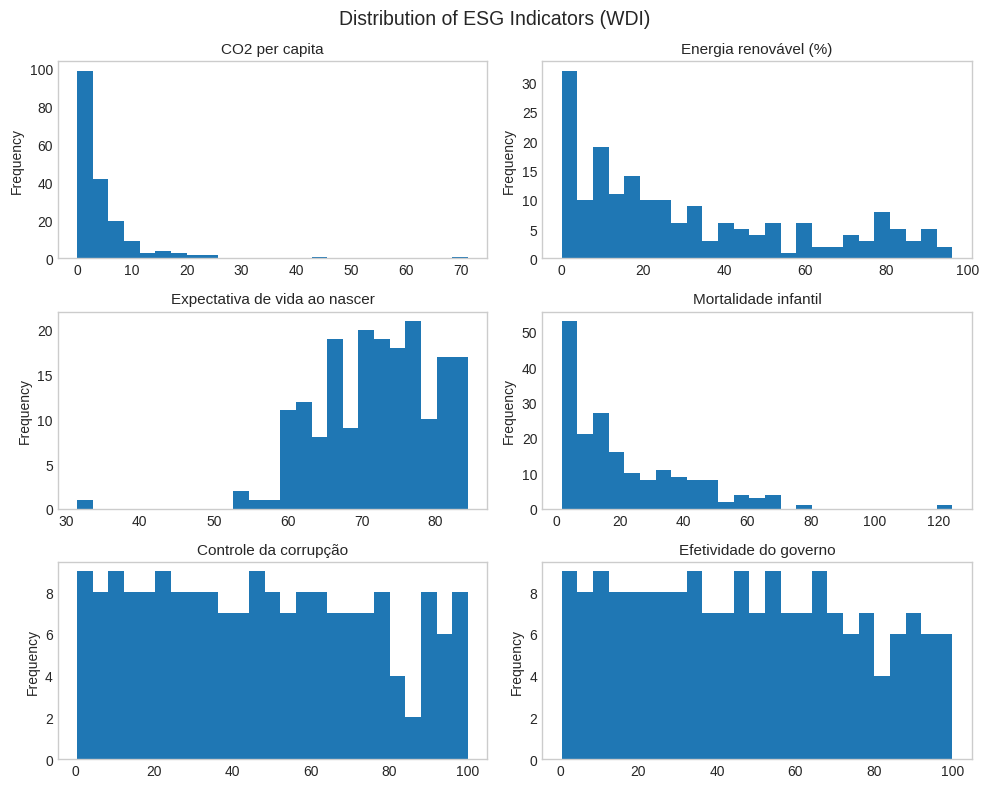

In [13]:
# Configuração de estilo
plt.style.use("seaborn-v0_8-whitegrid")

# Cria os histogramas
axes = df_model.hist(
    bins=25,
    figsize=(10, 8),
    grid=False,
)

# Ajusta títulos e layout
for ax in axes.flatten():
    ax.set_title(ax.get_title(), fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")
plt.suptitle("Distribution of ESG Indicators (WDI)", fontsize=14)
plt.tight_layout()
plt.savefig( # Exportação da figura
    "../images/distri_indicators.png",
    dpi=500,
    bbox_inches="tight"
)
# Exibe o gráfico 
plt.show()

---

## Aplicação da análise de similaridade entre os vetores de indicadores

Quando calculamos a **distância entre os países** considerando simultaneamente os seis indicadores ESG selecionados, alguns resultados chamam atenção. Países como Sri Lanka, Albânia e Colômbia aparecem entre os mais próximos do Brasil. Isso provavelmente **não seria intuitivo** em uma análise feita apenas “no olho” ou baseada em um único indicador.

**Esse é justamente o ponto**: quando tratamos cada país como um vetor de múltiplas dimensões, **a noção de “parecido” deixa de ser subjetiva e passa a ser definida matematicamente**. Em outras palavras, técnicas simples de análise multivariada podem revelar proximidades estruturais entre países que dificilmente seriam percebidas usando apenas médias ou comparações isoladas.

In [14]:
# Padronização dos indicadores
scaler = StandardScaler()

df_model_scaled = scaler.fit_transform(df_model)

df_model_scaled = pd.DataFrame(
    df_model_scaled,
    index=df_model.index,
    columns=df_model.columns
)

df_model_scaled.head()

,CO2 per capita,Energia renovável (%),Expectativa de vida ao nascer,Mortalidade infantil,Controle da corrupção,Efetividade do governo
country_name,,,,,,
Afghanistan,-0.584,-0.441,-1.153,1.823,-1.452,-1.427
Albania,-0.368,0.316,0.936,-0.689,-0.532,0.073
Algeria,-0.067,-1.110,0.457,-0.037,-0.666,-0.500
Angola,-0.515,0.706,-1.139,1.150,-1.151,-1.241
Antigua and Barbuda,-0.126,-1.092,0.645,-0.689,0.522,0.089


In [15]:
dist_matrix = pd.DataFrame(
    pairwise_distances(df_model_scaled, metric="euclidean"),
    index=df_model_scaled.index,
    columns=df_model_scaled.index
)

dist_matrix.head()

country_name,Afghanistan,Albania,Algeria,Angola,Antigua and Barbuda,Argentina,Armenia,Australia,Austria,Azerbaijan,"Bahamas, The",Bahrain,Bangladesh,Barbados,Belarus,Belgium,Belize,Benin,Bhutan,Bolivia,Bosnia and Herzegovina,Botswana,Brazil,Brunei Darussalam,Bulgaria,...,Syrian Arab Republic,Tajikistan,Tanzania,Thailand,Timor-Leste,Togo,Tonga,Trinidad and Tobago,Tunisia,Turkiye,Turkmenistan,Tuvalu,Uganda,Ukraine,United Arab Emirates,United Kingdom,United States,Uruguay,Uzbekistan,Vanuatu,"Venezuela, RB",Viet Nam,"Yemen, Rep.",Zambia,Zimbabwe
country_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0.000,3.793,2.871,1.378,4.046,3.794,3.517,6.123,5.707,2.982,4.259,5.432,2.175,4.680,3.959,5.538,3.173,1.968,4.766,2.068,3.546,3.372,3.436,5.323,4.000,...,2.193,2.155,2.792,3.831,1.635,2.439,3.631,4.600,3.521,3.756,2.132,3.058,3.005,3.222,6.078,5.618,5.658,5.124,2.731,2.968,2.266,3.240,1.214,2.825,2.309
Albania,3.793,0.000,1.768,3.158,1.799,1.357,1.297,3.490,2.701,1.689,2.601,3.496,1.694,2.418,1.725,2.766,1.337,3.412,2.845,2.153,1.056,2.898,0.698,3.287,1.348,...,2.701,2.029,2.849,0.878,2.786,3.407,1.733,3.508,1.341,1.112,3.008,2.527,2.932,1.479,3.699,2.851,3.194,2.275,1.913,1.392,2.350,1.062,3.332,3.142,3.739
Algeria,2.871,1.768,0.000,2.871,1.491,1.256,1.028,3.770,3.498,0.632,2.348,3.223,1.243,2.458,1.496,3.117,1.512,3.124,3.834,1.216,1.580,2.709,1.829,3.160,1.639,...,1.552,1.889,3.301,1.531,1.790,3.601,1.379,2.908,1.171,1.166,1.673,1.880,3.576,0.761,3.733,3.286,3.393,3.412,0.718,1.527,1.483,1.099,2.165,3.598,3.844
Angola,1.378,3.158,2.871,0.000,3.811,3.463,3.216,5.745,5.137,2.905,4.017,5.217,1.833,4.389,3.605,5.156,2.573,1.418,3.798,1.899,2.922,3.059,2.659,5.052,3.540,...,2.410,1.515,1.501,3.372,1.758,1.124,3.411,4.469,3.208,3.404,2.457,2.842,1.703,2.987,5.797,5.225,5.283,4.316,2.692,2.348,2.193,2.844,1.896,1.480,1.122
Antigua and Barbuda,4.046,1.799,1.491,3.811,0.000,0.487,0.715,2.655,2.309,1.527,1.270,2.895,2.339,1.123,0.699,1.822,1.534,3.662,3.233,2.198,1.939,2.469,1.904,2.296,1.006,...,2.882,2.921,3.751,1.333,2.585,4.236,1.061,2.918,0.701,0.847,2.964,1.708,4.196,1.447,2.865,1.947,2.315,2.450,1.906,1.659,2.795,1.350,3.480,4.119,4.662


In [16]:
# Países mais parecidos com o Brasil
top10_similar = dist_matrix.loc["Brazil"].sort_values(ascending=True).iloc[1:11]

In [17]:
# Define uma paleta personalizada (amarelo → verde → azul)
# Vamos usar esse mapa de cores para todos os gráficos comparativos
cmap = mcolors.LinearSegmentedColormap.from_list(
    "amarelo_verde_azul",
    ["#FDE725", "#90D743", "#35B779", "#1F9E89", "#31688E"]
)

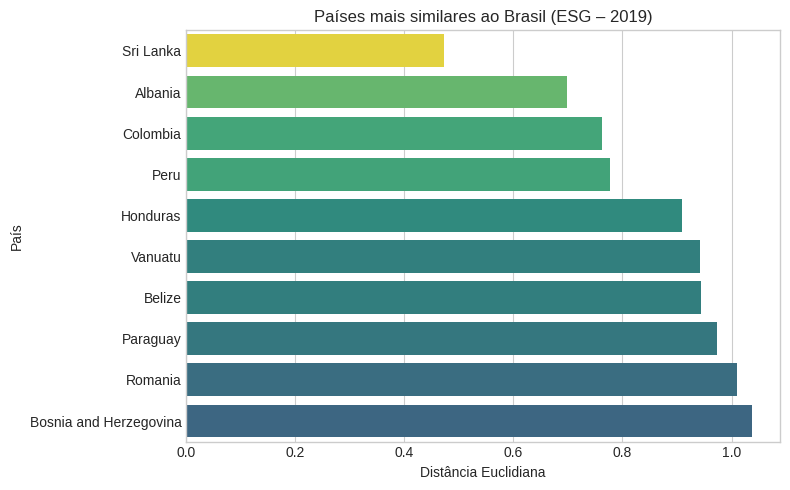

In [33]:
# cria uma cor para cada barra
norm = plt.Normalize(top10_similar.min(), top10_similar.max())
colors = [cmap(norm(v)) for v in top10_similar.values]

# plot
plt.figure(figsize=(8,5))
sns.barplot(
    x=top10_similar.values,
    y=top10_similar.index,
    palette=colors
)
plt.title("Países mais similares ao Brasil (ESG – 2019)")
plt.xlabel("Distância Euclidiana")
plt.ylabel("País")
plt.tight_layout()
plt.savefig( # Exportação da figura
    "../images/top10_similar.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

### Análise pontual
Após **padronizar** os indicadores ESG e **calcular a distância euclidiana** entre os países, é possível identificar quais apresentam perfil mais próximo ao do Brasil.

O resultado mostra que países como Sri Lanka, Albânia, Colômbia e Peru aparecem entre os mais próximos ao Brasil considerando simultaneamente os seis indicadores analisados.

Identificar países similares é apenas o primeiro passo. A próxima pergunta é entender **em quais dimensões essa similaridade aparece**.

Para entender melhor essa proximidade, o gráfico abaixo mostra o perfil padronizado dos indicadores ESG para o Brasil e para os países mais similares.

In [19]:
# Seleciona o Brasil e os 10 países mais similares para comparação
countries = ["Brazil"] + list(top10_similar.index)
df_compare = df_model_scaled.loc[countries]

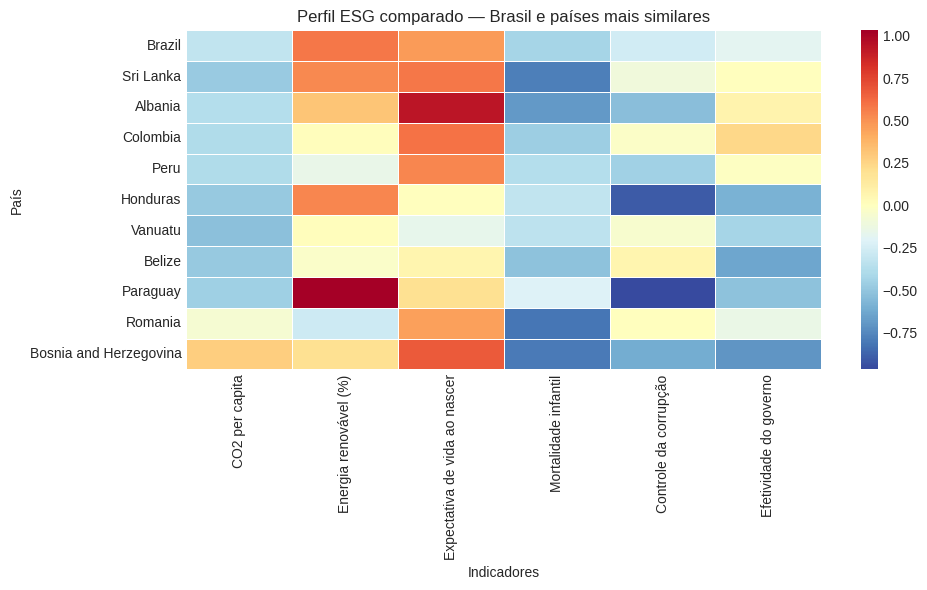

In [20]:
# Heatmap para comparar o perfil dos indicadores ESG entre o Brasil e os países mais similares
plt.figure(figsize=(10,6))
sns.heatmap(
    df_compare,
    cmap="RdYlBu_r",
    center=0,
    linewidths=0.5
)
plt.title("Perfil ESG comparado — Brasil e países mais similares")
plt.xlabel("Indicadores")
plt.ylabel("País")
plt.tight_layout()
plt.savefig( # Exportação da figura
    "../images/top10_matrix.png",
    dpi=500,
    bbox_inches="tight"
)
plt.show()

### O Heatmap

O mapa de calor mostra o perfil ESG padronizado do Brasil comparado aos dez países mais similares identificados pela análise de distância. Cada célula representa o desvio em relação à média global do indicador, permitindo observar rapidamente padrões de proximidade estrutural. 

De modo geral, a similaridade com o Brasil aparece principalmente nos indicadores sociais (expectativa de vida e mortalidade infantil) que apresentam valores relativamente próximos entre os países do grupo. Já as maiores diferenças surgem nas dimensões de governança, especialmente em controle da corrupção e efetividade do governo, onde alguns países apresentam desempenhos significativamente superiores ou inferiores ao Brasil.

Esse padrão sugere que países considerados “similares” ao Brasil no conjunto ESG tendem a compartilhar características sociais e ambientais intermediárias, enquanto ainda divergem de forma mais acentuada na qualidade da governança.

---
## Análise de Componentes Principais (PCA)

A aplicação de PCA (Principal Component Analysis) visa projetar os países em duas dimensões, permitindo visualizar a estrutura de similaridade ESG no espaço multivariado dos indicadores.

In [21]:
# Contribuição das variáveis na distância ao Brasil
brazil_vector = df_model_scaled.loc["Brazil"]

dist_components = (df_model_scaled - brazil_vector) ** 2

dist_components.head()

,CO2 per capita,Energia renovável (%),Expectativa de vida ao nascer,Mortalidade infantil,Controle da corrupção,Efetividade do governo
country_name,,,,,,
Afghanistan,0.067,1.045,2.645,5.086,1.411,1.554
Albania,0.002,0.070,0.214,0.066,0.072,0.064
Algeria,0.067,2.859,0.000,0.156,0.161,0.102
Angola,0.036,0.016,2.600,2.504,0.786,1.126
Antigua and Barbuda,0.040,2.798,0.029,0.066,0.618,0.073


In [22]:
# Estrutura ESG dos países (PCA)
pca = PCA(n_components=2)

pca_df = pd.DataFrame(
    pca.fit_transform(df_model_scaled),
    columns=["PC1", "PC2"],
    index=df_model_scaled.index
)

### O scatter plot
O gráfico abaixo apresenta uma **projeção** dos países no espaço formado pelos indicadores ESG utilizando **Análise de Componentes Principais (PCA)**. Cada ponto representa um país, posicionado de acordo com a combinação dos indicadores analisados. O Brasil aparece próximo de um grupo de países que também foram identificados como **similares na análise de distância**, sugerindo que esses **países ocupam uma região semelhante** no espaço multivariado formado pelos indicadores ESG.

É importante lembrar que a distância utilizada na análise é calculada no espaço completo dos indicadores (distância real em 6 dimensões), enquanto o gráfico de PCA mostra apenas uma projeção bidimensional (distância visual em 2 dimensões).

Como o PCA projeta os dados em duas dimensões, algumas relações de proximidade observadas no espaço completo de indicadores podem não aparecer perfeitamente representadas no gráfico.

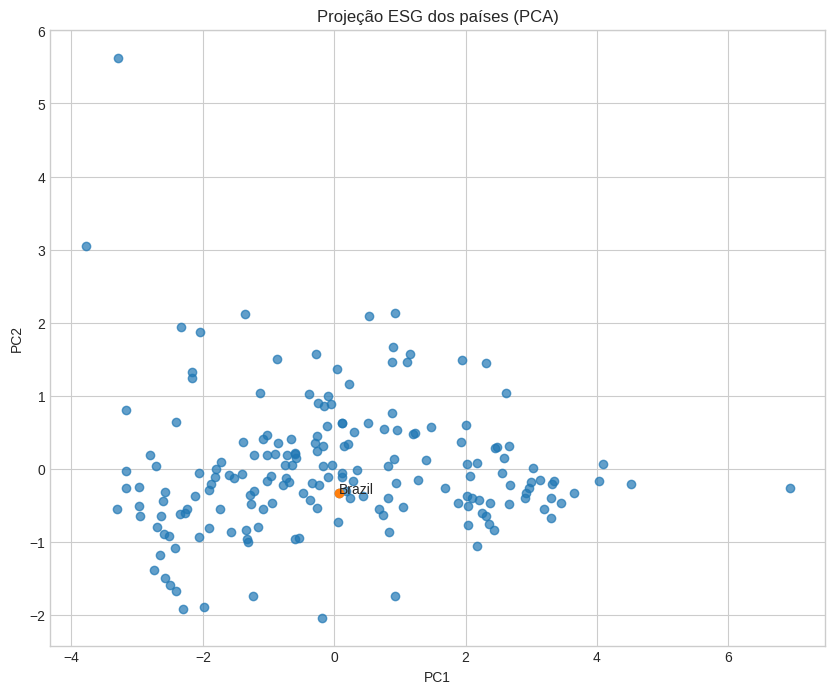

In [23]:
# Visualização do espaço ESG
plt.figure(figsize=(10,8))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.7)
for country in ["Brazil"]:
    x = pca_df.loc[country, "PC1"]
    y = pca_df.loc[country, "PC2"]
    plt.scatter(x, y)
    plt.text(x, y, country)
plt.title("Projeção ESG dos países (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

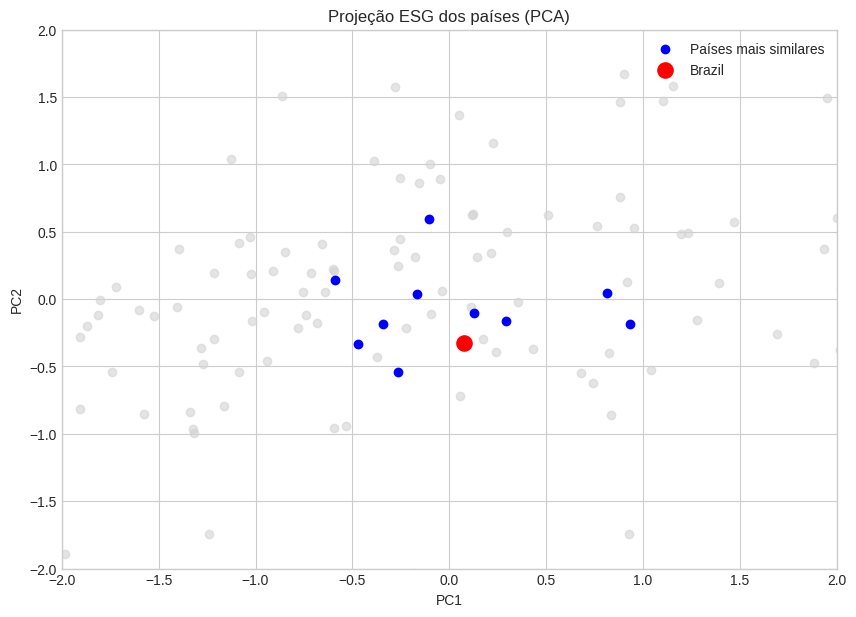

In [24]:
# Plot de zoom no centro da distribuição
plt.figure(figsize=(10,7))
# todos os países
plt.scatter(pca_df.PC1, pca_df.PC2, color="lightgray", alpha=0.6)
# top 10 similares
plt.scatter(
    pca_df.loc[top10_similar.index, "PC1"],
    pca_df.loc[top10_similar.index, "PC2"],
    color="blue",
    label="Países mais similares"
)
# Brasil
plt.scatter(
    pca_df.loc["Brazil", "PC1"],
    pca_df.loc["Brazil", "PC2"],
    color="red",
    s=120,
    label="Brazil"
)
plt.title("Projeção ESG dos países (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.legend()
plt.savefig( # Exportação da figura
    "../images/esg_pca.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Insight curioso

**O Brasil está relativamente no ponto central da distribuição!!**

No espaço formado pelos indicadores analisados, o Brasil aparece **próximo ao centro da distribuição** dos países, sugerindo um perfil ESG intermediário dentro do conjunto analisado. 

Esse **resultado é consistente com a posição geralmente ocupada pelo país em rankings internacionais** de sustentabilidade e desempenho ambiental, nos quais o Brasil tende a aparecer em posições intermediárias, e não entre os extremos superiores ou inferiores.

> **Nota**: Posição do Brasil no Environmental Performance Index (EPI) 2020: 55° (https://epi.yale.edu/epi-results/2020/country/bra)

---
## Visualização geral das distâncias dos países em relação ao Brasil

Esta seção apresenta uma visão geral das distâncias calculadas entre o Brasil e os demais países, permitindo identificar quais apresentam maior ou menor similaridade no espaço dos indicadores ESG analisados, a partir da organização e ordenação desses valores em um dataframe estruturado para facilitar a análise e visualização.

In [25]:
# Baixar o Geodataset

# Carrega mapa mundial (Natural Earth)
url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"

# Filtro das colunas necessárias
world = gpd.read_file(url)[["ADMIN", "geometry"]]

In [26]:
# Organiza as distâncias dos países em relação ao Brasil em formato de tabela
dist_matrix_map = dist_matrix.loc["Brazil"].sort_values().reset_index()
dist_matrix_map.columns = ["country_name", "distance_to_brazil"]

In [27]:
# Padroniza alguns nomes de países 
name_fix = {
    "United States": "United States",
    "Russian Federation": "Russia",
    "Egypt, Arab Rep.": "Egypt",
    "Iran, Islamic Rep.": "Iran",
    "Viet Nam": "Vietnam",
    "Korea, Rep.": "South Korea",
}
dist_matrix_map["country_name"] = dist_matrix_map["country_name"].replace(name_fix)

In [28]:
# Junta os dados de distância ao Brasil com o dataset geográfico dos países
world = world.merge(
    dist_matrix_map,
    how="left",
    left_on="ADMIN",
    right_on="country_name"
)

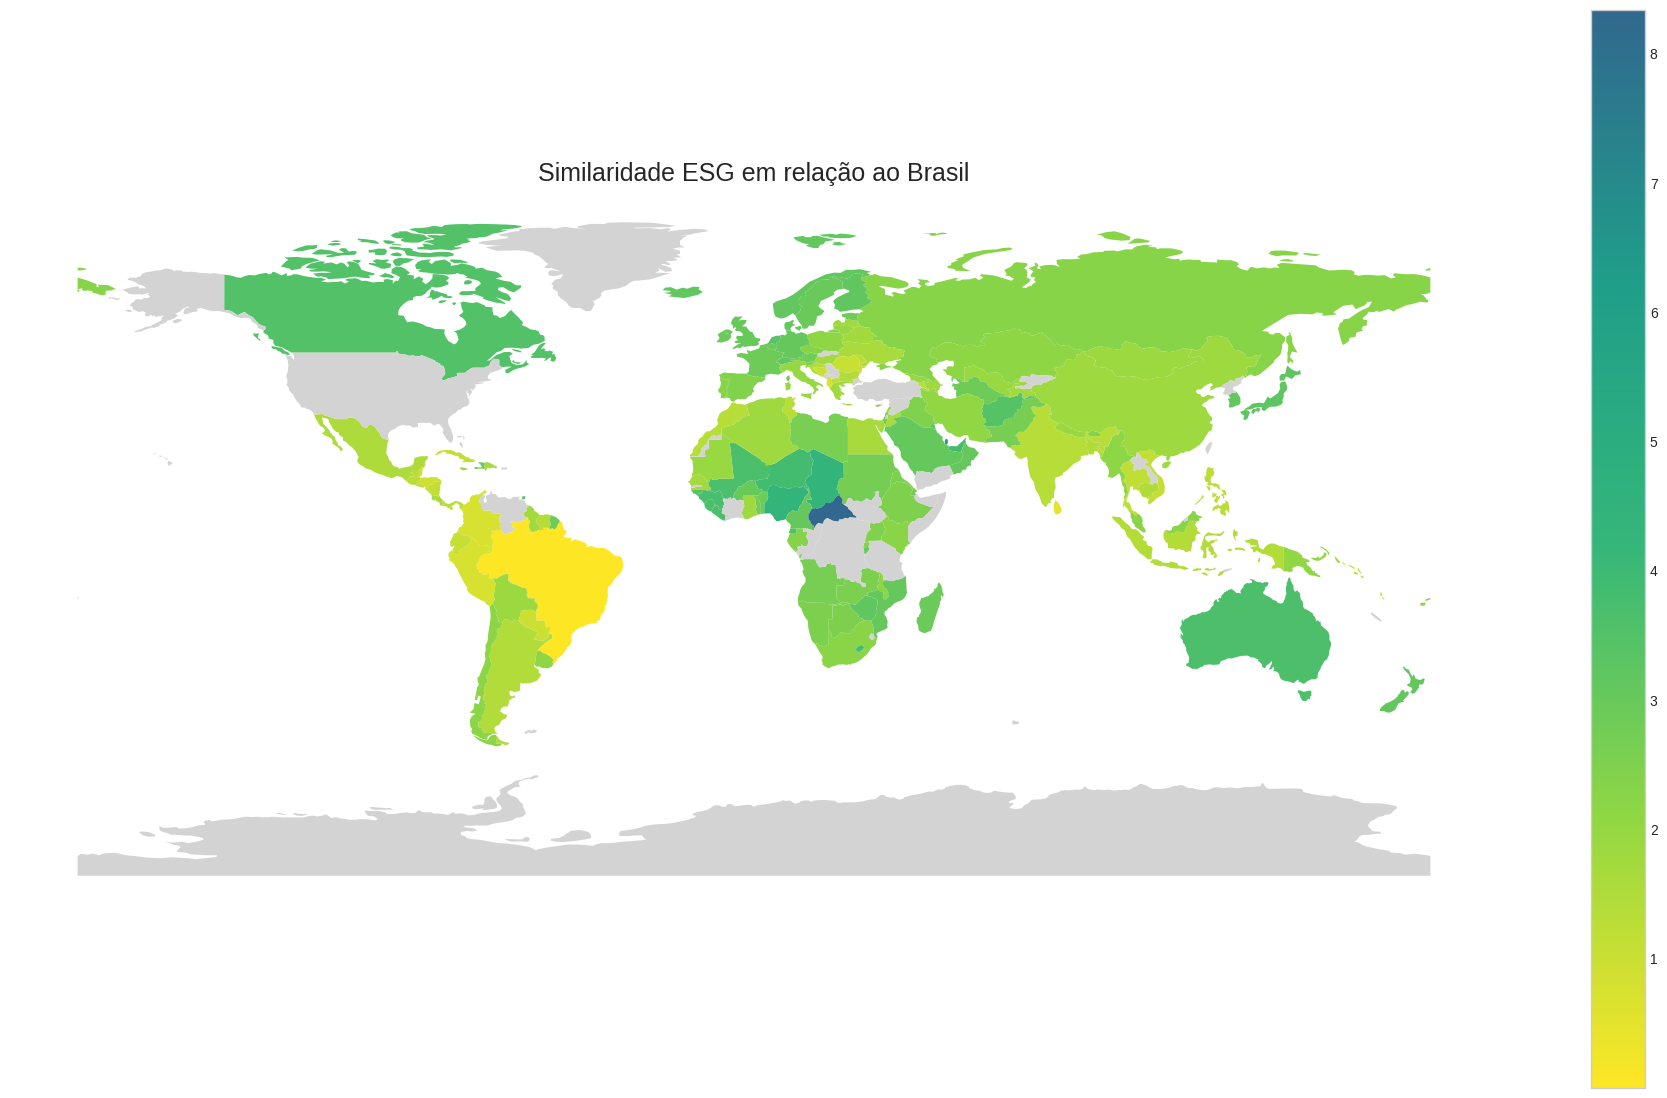

In [32]:
# Plota o mapa mundial colorido pela distância ESG em relação ao Brasil
fig, ax = plt.subplots(figsize=(24,14))

world.plot(
    column="distance_to_brazil",
    cmap=cmap,
    legend=True,
    missing_kwds={"color": "lightgrey"},
    ax=ax
)

ax.set_title(
    "Similaridade ESG em relação ao Brasil",
    fontsize=18
)

ax.axis("off")

plt.savefig(
    "../images/esg_distance_brazil_worldmap.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### Mapa mundi

O mapa acima **mostra a distância euclidiana** entre o Brasil e todos os países do conjunto analisado, considerando simultaneamente os seis indicadores ESG utilizados no experimento. Cada país é colorido de acordo com sua distância no espaço de indicadores: valores menores (**mesmas cores**) indicam maior **similaridade** com o Brasil, enquanto valores maiores (**cores diferentes**) indicam **perfis mais distantes**.

A visualização permite observar como o Brasil se posiciona em relação ao conjunto completo de países analisados, evidenciando que a similaridade não é distribuída de forma uniforme e que diferentes regiões apresentam graus distintos de proximidade no espaço multivariado formado pelos indicadores ESG.

## Principais Resultados Observados

- Países podem apresentar **perfis ESG semelhantes mesmo sem proximidade geográfica**.  
- A análise baseada em vetores permite considerar **simultaneamente múltiplos indicadores**.  
- **Métricas de distância** oferecem uma forma sistemática de comparar estruturas ESG entre países.